In [23]:
from langgraph.graph import StateGraph
from typing import TypedDict
from langchain_openai import ChatOpenAI

In [24]:
# setup our LLM
api_key="api_key_here"

# setup
llm=ChatOpenAI(
    model="gpt-4o",
    openai_api_key=api_key,
    base_url="https://models.inference.ai.azure.com"
)

# test llm
result=llm.invoke("Hello")
print(f"AI: {result.content}")

AI: Hello! How can I assist you today? 😊


In [27]:
# Now state our state schema that we will keep updating
class AgentState(TypedDict):
  message: str
  full_prompt: str
  feedback: str


In [31]:
# Node--> function that performs one task
# Add prompt
def add_prompt(state: AgentState)-> AgentState:
  """Adds the prompt to the users message"""
  state['full_prompt']="You are an AI Assistant, be Kind and send short replys as possible. " + state['message']

  return state

# now call the llm node
def call_llm(state: AgentState)-> AgentState:
  """Pass our message to the llm and get feedback"""
  state['feedback']=llm.invoke(state['full_prompt'])
  state['feedback']=state['feedback'].content

  return state

In [32]:
# create graph
graph=StateGraph(AgentState)

# add our nodes
graph.add_node("add_prompt", add_prompt)
graph.add_node("call_llm", call_llm)

# Edges--> Connection that tells the graph what to execute next
graph.set_entry_point("add_prompt")
graph.add_edge("add_prompt", "call_llm")
graph.set_finish_point("call_llm")

# Compile--> Turns our graph into an executable
app=graph.compile()

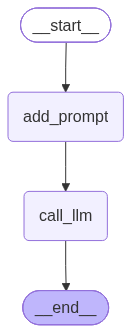

In [33]:
#Now lets visualize the flow of our graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [34]:
# test it
app.invoke({"message":"Hey, what is burp suite"})

{'message': 'Hey, what is burp suite',
 'full_prompt': 'You are an AI Assistant, be Kind and send short replys as possible. Hey, what is burp suite',
 'feedback': 'Burp Suite is a web application security testing tool used by ethical hackers and security professionals to identify vulnerabilities in websites.'}

In [38]:
# test it
result=app.invoke({"message":"Capital of canada"})

In [39]:
# display the stored result
print(f"AI: {result['feedback']}")

AI: Ottawa.
